In [1]:
from spectral_spatial_simulation import LookupTableWET2
from prettyconsole import Console
from file import Configurator
import file
from tools import JupyterPlotManager
from tools import ArrayTools

%matplotlib ipympl

In [2]:
# Fixed input variables for the Bloch Simulation
TR = 600   # [ms]
TE = 0     # [ms]
T2 = 250   # [ms]
flip_angle_excitation = 47.0           # [°] # Why exactly this flip angle?
flip_angles_WET = [89.2, 83.4, 160.8]  # [°] Why exactly this flip angles?
time_gaps_WET = [30, 30, 30]           # [ms]

# Variables containing range for generating the dictionary
T1_step_size = 50      # [ms]
T1_range = [300, 5000] # [ms]

# What is this?
B1_scales_inhomogeneity = [1e-10,3] # Maybe this is the possible range due to the inhomogeneities?
B1_scales_gauss = [0.01, 1]         # Maybe this is the possible range of the gauss excitation pulse?
B1_scales_inhomogeneity_step_size = 0.05
B1_scales_gauss_step_size=0.05


off_resonance=0

# To simulate the evolution of M = (Mx, My, Mz) of a spin system during a WET sequence + final excitation pulse.
lookup_table_WET_test = LookupTableWET2(T1_range=T1_range,                      #### TODO: describe each of them
                                       T1_step_size=T1_step_size,
                                       T2=T2,
                                       B1_scales_inhomogeneity=B1_scales_inhomogeneity, # TODO
                                       B1_scales_gauss=B1_scales_gauss,
                                       B1_scales_inhomogeneity_step_size=B1_scales_inhomogeneity_step_size,
                                       B1_scales_gauss_step_size=B1_scales_gauss_step_size,
                                       TR=TR,
                                       TE=TE, # TODO -> why 0???
                                       flip_angle_excitation_degree=flip_angle_excitation,
                                       flip_angles_WET_degree=flip_angles_WET,
                                       time_gaps_WET=time_gaps_WET,
                                       off_resonance=off_resonance)

lookup_table_WET_test.create()

[  1  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  0.050 | Range:  0.000: 3.000
                       => Axis 2: T1/TR    | Resolution:  0.083 | Range:  0.500: 8.333
         START TIMER          
[  2  ][ success ] >> NaNs are NOT present!                                                                                
[  3  ][ success ] >> Infs are NOT present!                                                                                
[  4  ][  info   ] >> Found number of zeros: 0                                                                             
        TOOK 0.073 sec        
[  5  ][ success ] >> Created WET lookup table with 5795 entries.Values Range: [2.8850151969148033e-05, 1.0]               


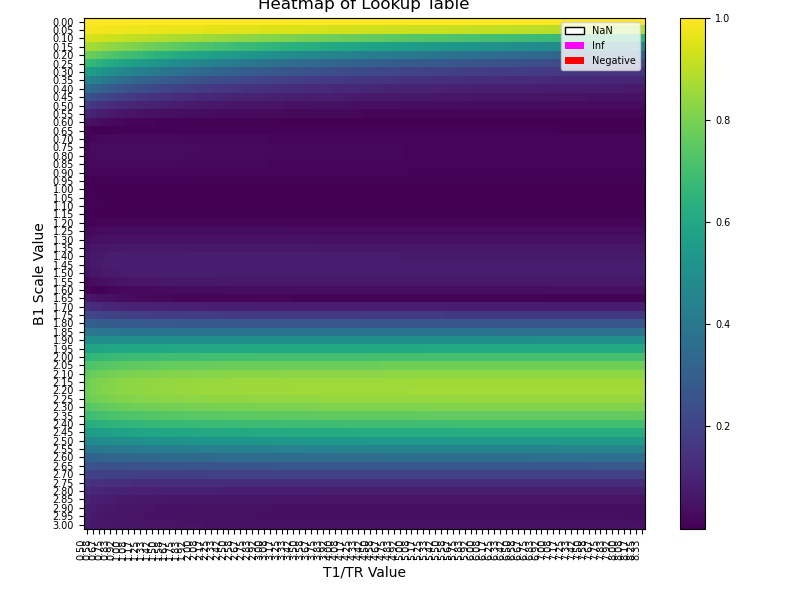

In [9]:
lookup_table_WET_test.plot()

In [10]:
from file import ParameterMaps, Configurator

In [11]:
config_file_name = "paths_09012026.json"
configurator = Configurator(path_folder="../config/",
                            file_name=config_file_name)
configurator.load()

In [12]:
target_gpu_interpolation = 1

loaded_B1_map = file.ParameterMaps(configurator=configurator, map_type_name="B1").load_file().to_working_volume().maps[0]
loaded_T1_map = file.ParameterMaps(configurator=configurator, map_type_name="T1").load_file().to_working_volume().maps[0].interpolate(target_size=loaded_B1_map.values.shape, order=1, device="gpu", target_gpu=target_gpu_interpolation)

[ 24  ][  info   ] >> Maps object: The provided path points to a file                                                      
[ 25  ][  error  ] >> Could not convert loaded unit 'unknown' to pint unit. Therefore, assigned 'dimensionless'!           
[ 26  ][  info   ] >> Loading nii file for map type B1                                                                     
[ 27  ][ success ] >> NaNs are NOT present!                                                                                
[ 28  ][ success ] ---v  (collected several lines)                      
                      Loaded nii map: B1Map_TargetRes.nii | Shape: (180, 180, 109) | Values range: [-19.237, 102.543] | Unit: None | Unique values: 334682
                      
[ 29  ][ success ] ---v                       
                      Created 4D volume of metabolite maps: ['B1']. 
                       Map type: ....... B1 
                       Unit: ........... None 
                       Shape: .......... (1, 

In [13]:
b1_scales = loaded_B1_map.values/39.0
b1_scales = ArrayTools.enforce_min_eps(b1_scales, convert_zeros=False)
t1_over_tr = loaded_T1_map.values / TR

fetched_values = lookup_table_WET_test.get(b1_scales=b1_scales, t1_over_tr=t1_over_tr)

[ 36  ][ success ] >> Converted negative values to eps: 2.220446049250313e-16                                              
[ 37  ][  info   ] ---v  (automatic line breaks) 
                      Extrapolation is activated (nearest-value extrapolation). Double check retrieved values outside the
                      WET lookup table!
[ 38  ][ success ] >> NaNs are NOT present!                                                                                


In [14]:


ArrayTools.check_nan(fetched_values)
ArrayTools.check_inf(fetched_values)
ArrayTools.count_zeros(fetched_values)

[ 39  ][ success ] >> NaNs are NOT present!                                                                                
[ 40  ][ success ] >> Infs are NOT present!                                                                                
[ 41  ][  info   ] >> Found number of zeros: 0                                                                             


0

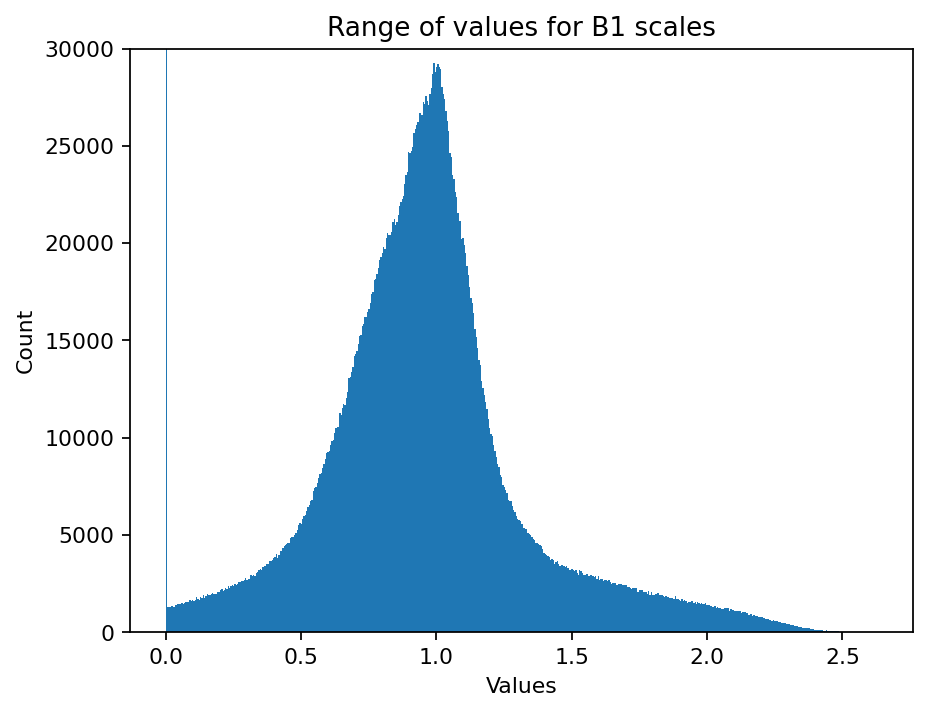

In [15]:
import matplotlib.pyplot as plt

fig = plt.figure()
plt.title("Range of values for B1 scales")
plt.hist(b1_scales.ravel(), bins="auto")
plt.ylim([0, 30000])
plt.ylabel("Count")
plt.xlabel("Values")
display(fig)
plt.close()

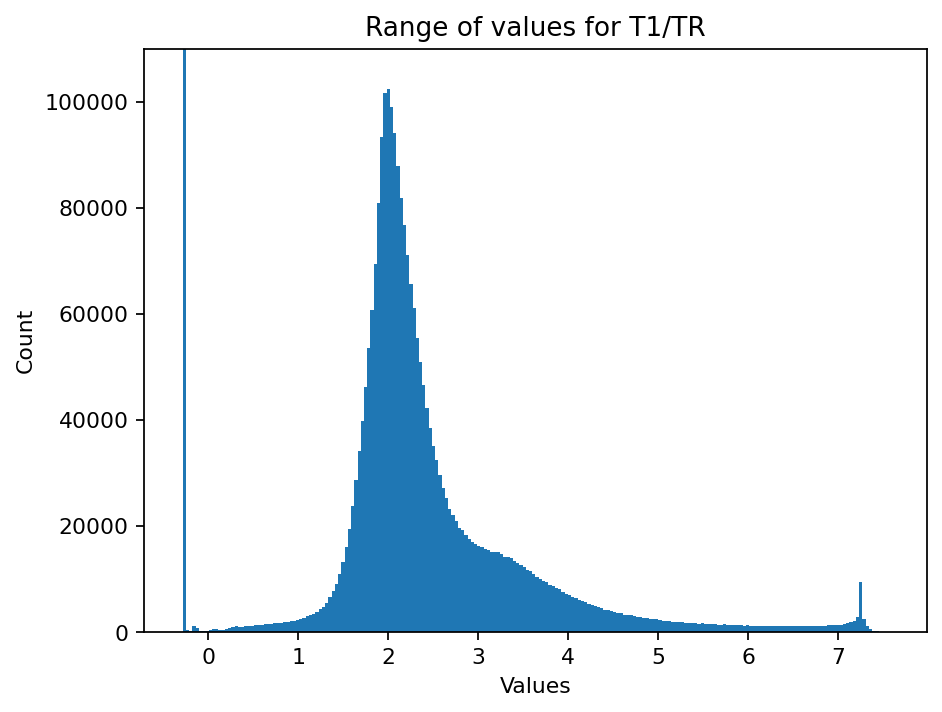

In [16]:
fig = plt.figure()
plt.title("Range of values for T1/TR")
plt.hist(t1_over_tr.ravel(), bins="auto")
plt.ylim([0, 110000])
plt.ylabel("Count")
plt.xlabel("Values")
display(fig)
plt.close()

In [17]:
# => Axis 1: B1 scale | Resolution:  0.050 | Range:  0.000: 3.000
# => Axis 2: T1/TR    | Resolution:  0.083 | Range:  0.500: 8.333

In [15]:
lookup_table_WET_test.simulated_data.dtype

dtype('float64')

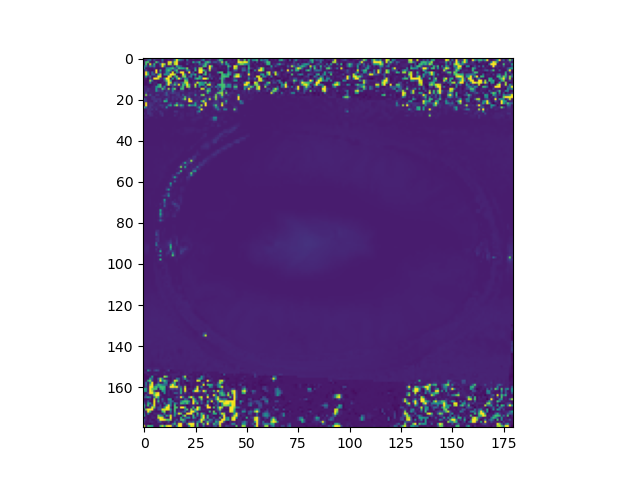

In [23]:
plt.figure()
plt.imshow(fetched_values[:, :, 40])
plt.show()